In [1]:
# 1. Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [2]:
# 2. Importing the dataset and extracting the independent and dependent variables
companies = pd.read_csv("E:/ML-Learning/Linear Regression/1000_Companies.csv")
X = companies.iloc[:, :-1].values
y = companies.iloc[:, 4].values

companies.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


<Axes: >

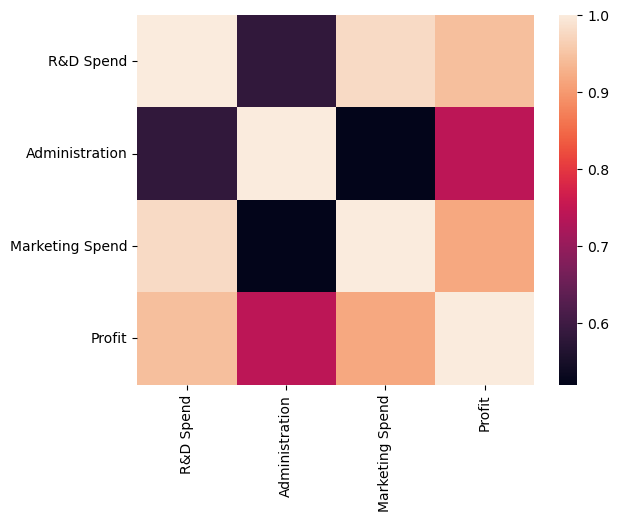

In [4]:
# 3. Data visualizaton
# Building the Correlation matrix
sns.heatmap(companies.corr(numeric_only = True))



In [5]:
# 4. Encoding Categorical Data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers = [
        ("encoding", OneHotEncoder(), [3])
    ],
    remainder = "passthrough"
)

X = ct.fit_transform(X)

In [6]:
# 5. Avoidind the Dummy Variable Trap
X = X[:, 1:]

In [7]:
# 6. Splitting the dataset into the training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [8]:
# 7. Fitting Multiple linear regression to the training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# 8. Predicting the test set results
y_pred = regressor.predict(X_test)
y_pred

array([ 89790.61532915,  88427.0718736 ,  94894.67836971, 175680.86725612,
        83411.73042088, 110571.90200074, 132145.22936441,  91473.37719686,
       164597.05380608,  53222.82667399,  66950.19050988, 150566.43987005,
       126915.20858596,  59337.85971049, 177513.91053063,  75316.2814305 ,
       118248.14406603, 164574.40699903, 170937.2898107 , 182069.11645086,
       118845.03252688,  85669.95112228, 180992.59396145,  84145.08220144,
       105005.83769214, 101233.56772746,  53831.07669089,  56881.41475223,
        68896.39346904, 210040.00765885, 120778.72270894, 111724.87157654,
       101487.90541517, 137959.02649624,  63969.95996742, 108857.91214126,
       186014.72531989, 171442.64130748, 174644.26529206, 117671.49128195,
        96731.37857433, 165452.2577941 , 107724.34331255,  50194.54176912,
       116513.89532179,  58632.48986819, 158416.46827611,  78541.48521609,
       159727.66671744, 131137.87699644, 184880.70924518, 174609.08266881,
        93745.66352058,  

In [10]:
# 9. Calculating the Coefficients
print(regressor.coef_)


[-8.80536598e+02 -6.98169073e+02  5.25845857e-01  8.44390881e-01
  1.07574255e-01]


In [11]:
# 10. calculating the intercept
print(regressor.intercept_)

-51035.22972404634


In [12]:
# 11. Evaluating the model
#calculating the R squared value
# R squred value of 0.91 proves the model is a good model 
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9112695892268822